In [1]:
import os
import sys

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from project.model.coherence_from_data import auto_coherence, show_coherence, coherence
from project.model.detection import show_photons, Spad23, Spad512, merge_photons
from project.model.sample import Alexa647
from project.model.setup import Setup, ScanningSetup, WidefieldSetup

import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from abc import ABC, abstractmethod


np.random.seed(42)

# Set the global font to be DejaVu Sans, size 10 (or any other font you prefer)
plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'monospace'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']

# Font sizes for different elements
plt.rcParams['font.size'] = 15          # Base font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 15     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 15    # X tick label font size
plt.rcParams['ytick.labelsize'] = 15    # Y tick label font size
plt.rcParams['legend.fontsize'] = 18    # Legend font size
plt.rcParams['figure.titlesize'] = 16   # Figure title font size

# Font weight
plt.rcParams['axes.labelweight'] = 'normal'  # Options: 'normal', 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Figure and axes settings
plt.rcParams['figure.figsize'] = (8, 6)     # Default figure size (width, height)
plt.rcParams['figure.dpi'] = 100            # Figure resolution
plt.rcParams['savefig.dpi'] = 300           # Saved figure resolution (high quality for thesis)
plt.rcParams['savefig.format'] = 'pdf'      # Default save format (PDF is vector format, good for thesis)
plt.rcParams['savefig.bbox'] = 'tight'      # Remove extra whitespace when saving

# Line and marker settings
plt.rcParams['lines.linewidth'] = 2.0       # Default line width
plt.rcParams['lines.markersize'] = 6        # Default marker size
plt.rcParams['lines.markeredgewidth'] = 1.0 # Marker edge width

# Axes settings
plt.rcParams['axes.linewidth'] = 1.2        # Axes border line width
plt.rcParams['axes.spines.top'] = False     # Remove top spine
plt.rcParams['axes.spines.right'] = False   # Remove right spine
plt.rcParams['axes.grid'] = False            # Enable grid by default
plt.rcParams['grid.alpha'] = 0.3            # Grid transparency
plt.rcParams['grid.linewidth'] = 0.8        # Grid line width

# Tick settings
plt.rcParams['xtick.major.size'] = 5        # X major tick size
plt.rcParams['xtick.minor.size'] = 3        # X minor tick size
plt.rcParams['ytick.major.size'] = 5        # Y major tick size
plt.rcParams['ytick.minor.size'] = 3        # Y minor tick size
plt.rcParams['xtick.major.width'] = 1.2     # X major tick width
plt.rcParams['xtick.minor.width'] = 0.8     # X minor tick width
plt.rcParams['ytick.major.width'] = 1.2     # Y major tick width
plt.rcParams['ytick.minor.width'] = 0.8     # Y minor tick width
plt.rcParams['xtick.direction'] = 'in'      # Tick direction: 'in', 'out', 'inout'
plt.rcParams['ytick.direction'] = 'in'

# Legend settings
plt.rcParams['legend.frameon'] = True       # Legend frame
plt.rcParams['legend.framealpha'] = 0.9     # Legend frame transparency
plt.rcParams['legend.fancybox'] = True      # Rounded corners for legend
plt.rcParams['legend.numpoints'] = 1        # Number of points in legend for line plots

# LaTeX settings (optional - for high-quality mathematical expressions)
plt.rcParams['text.usetex'] = False         # Set to True if you have LaTeX installed
plt.rcParams['mathtext.default'] = 'regular'  # Math font style

# Color settings - you can define a custom color palette
thesis_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=thesis_colors)

Plot with the PSF's

Starting scanning experiment: 1×1 μm area...
Manually created 1 emitter(s). All 1 emitters are within bounds (-0.5, 0.5, -0.5, 0.5)
Running scan...
Starting scan of 1×1 µm² area with 20×20 positions
Step size: 0.050 × 0.050 µm
ISM processing enabled with alpha=0.5
Progress: 2.5% (10/400), Est. remaining time: 662.2s
Progress: 5.0% (20/400), Est. remaining time: 392.5s
Progress: 7.5% (30/400), Est. remaining time: 290.7s
Progress: 10.0% (40/400), Est. remaining time: 244.3s
Progress: 12.5% (50/400), Est. remaining time: 214.0s
Progress: 15.0% (60/400), Est. remaining time: 198.6s
Progress: 17.5% (70/400), Est. remaining time: 182.6s
Progress: 20.0% (80/400), Est. remaining time: 175.2s
Progress: 22.5% (90/400), Est. remaining time: 167.7s
Progress: 25.0% (100/400), Est. remaining time: 158.3s
Progress: 27.5% (110/400), Est. remaining time: 149.9s
Progress: 30.0% (120/400), Est. remaining time: 143.8s
Progress: 32.5% (130/400), Est. remaining time: 136.9s
Progress: 35.0% (140/400), Est. 

C:\Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm\project\model\coherence_from_data.py:52: RuntimeWarning: divide by zero encountered in divide
  correlation = photon_pairs * (m / bias)
C:\Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm\project\model\coherence_from_data.py:52: RuntimeWarning: invalid value encountered in multiply
  correlation = photon_pairs * (m / bias)
C:\Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm\project\model\coherence_from_data.py:745: RuntimeWarning: invalid value encountered in divide
  pixel_neighbourhood_coherence /= pixel_neighbourhood_coherence[-100:].mean(axis=0)
C:\Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm\project\model\coherence_from_data.py:745: RuntimeWarning: divide by zero encountered in divide
  pixel_neighbourhood_coherence /= pixel_neighbourhood_coherence[-100:].mean(axis=0)


Fitting with high uncertainty at position (12, 5): n=1.59, sigma=0.8651671792915494. Setting estimate at average of surrounding area.
Fitting with high uncertainty at position (14, 6): n=1.22, sigma=0.6496012115929412. Setting estimate at average of surrounding area.
Fitting with high uncertainty at position (15, 8): n=1.32, sigma=0.8094574141519182. Setting estimate at average of surrounding area.
Fitting with high uncertainty at position (15, 9): n=1.12, sigma=0.6162488908259802. Setting estimate at average of surrounding area.
Fitting with high uncertainty at position (15, 10): n=1.59, sigma=1.0588404860635974. Setting estimate at average of surrounding area.
Fitting with high uncertainty at position (15, 11): n=1.1, sigma=0.6022348739665537. Setting estimate at average of surrounding area.
Fitting with high uncertainty at position (14, 13): n=1.26, sigma=0.7148205716588792. Setting estimate at average of surrounding area.
NR EMITTERS MAP
[[0.         0.         0.         0.       

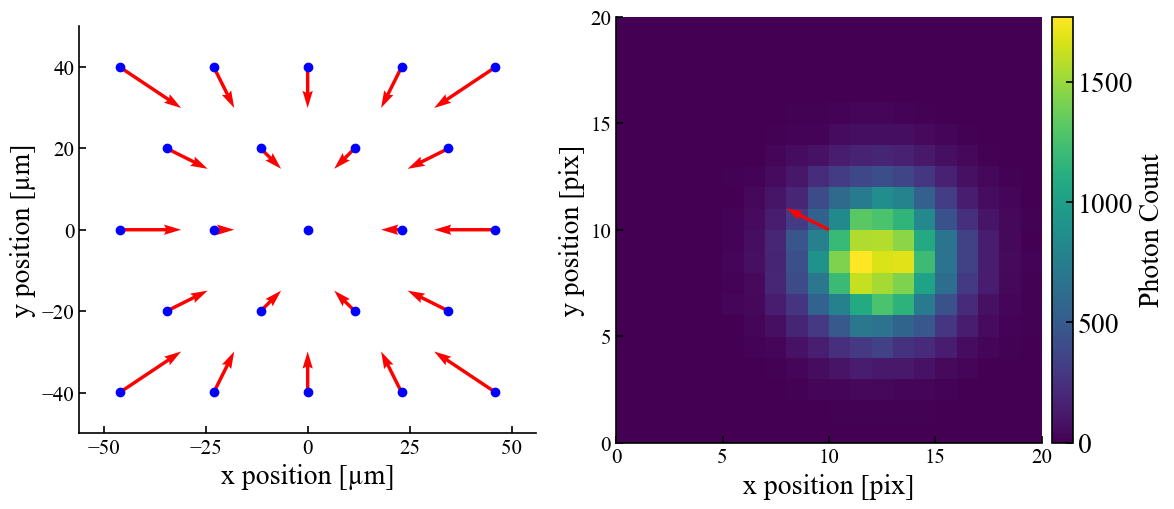

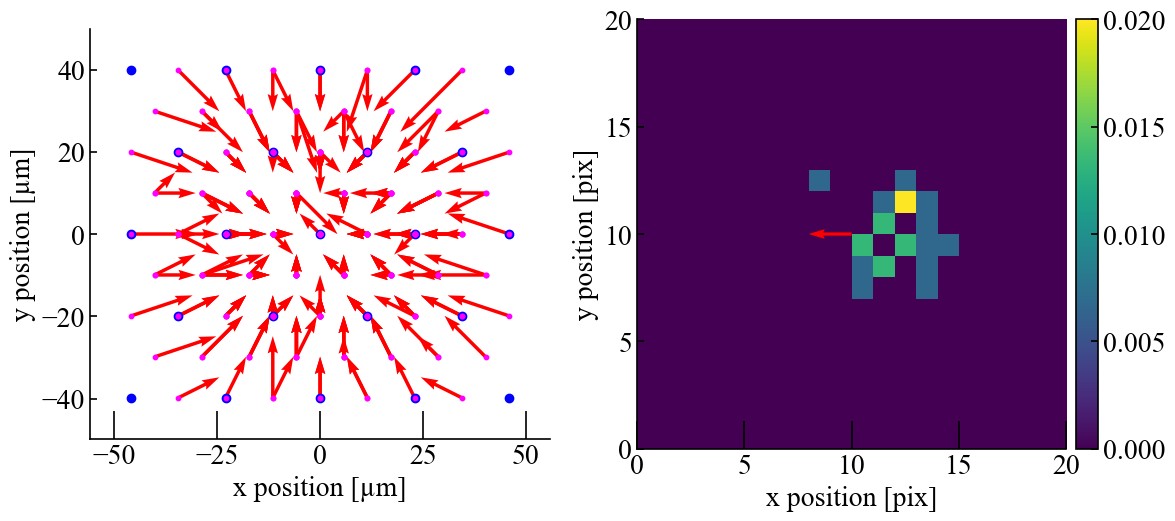

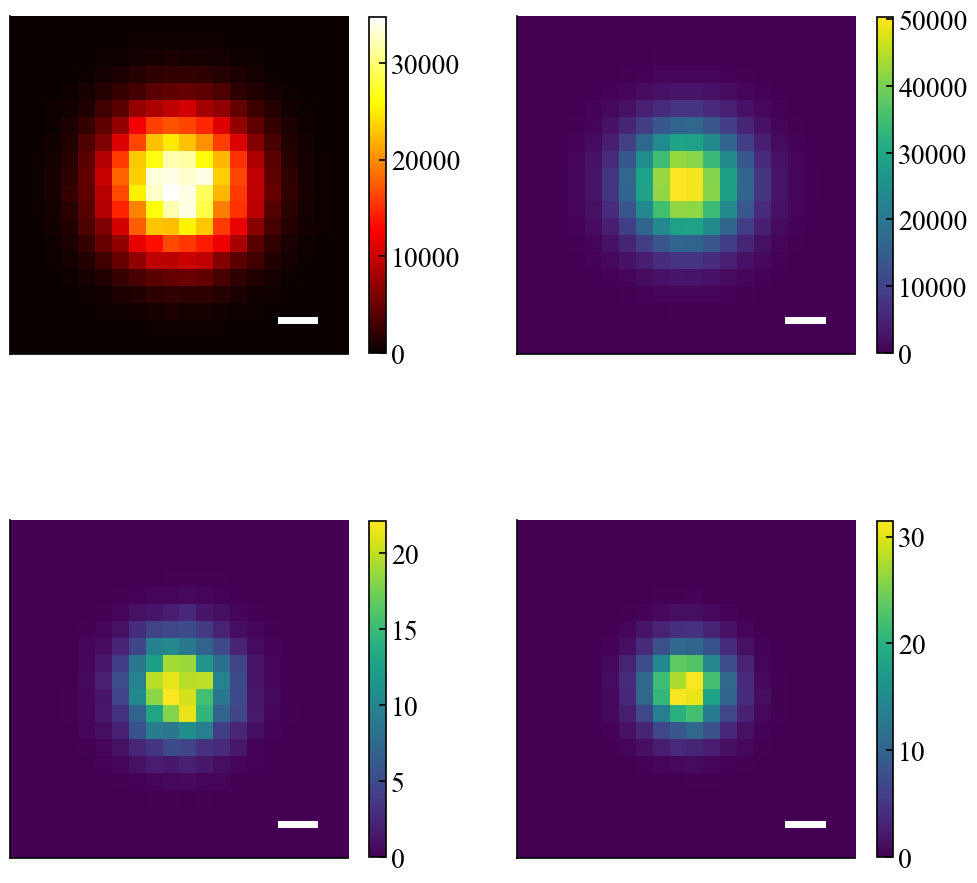

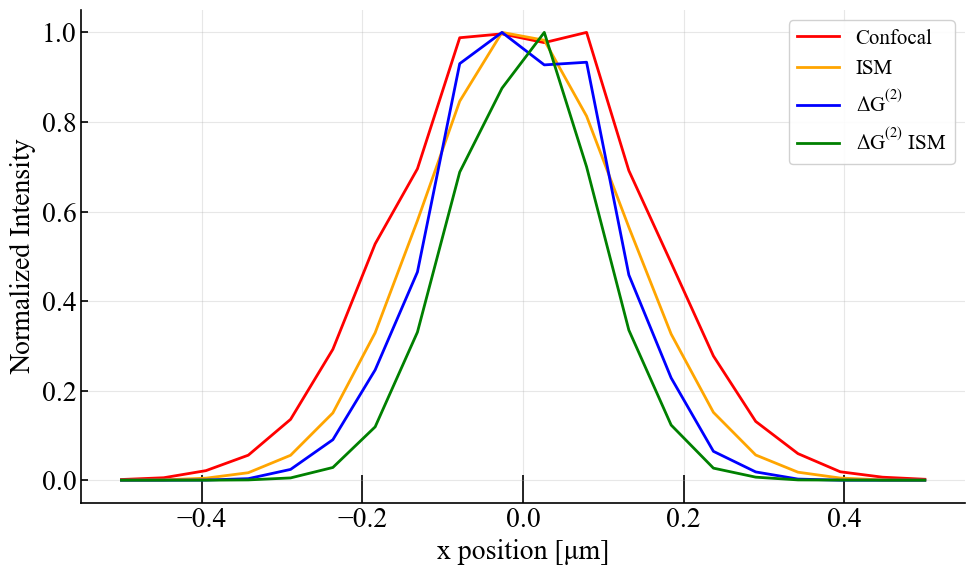

Confocal sigma (μm): 0.1472
ISM sigma (μm): 0.1219
G² Confocal sigma (μm): 0.1076
G² ISM sigma (μm): 0.0902
ISM processing completed in 21.54 seconds
Generating plots...
Calculation summary: 359 successful calculations, 0 failed calculations, 1 skipped due to low photon count (<10)


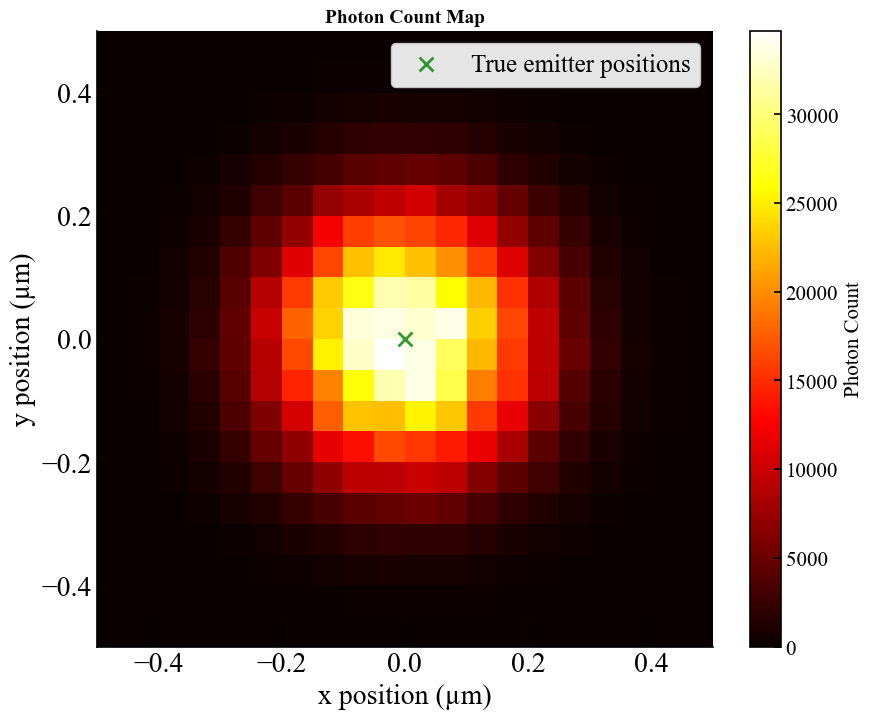

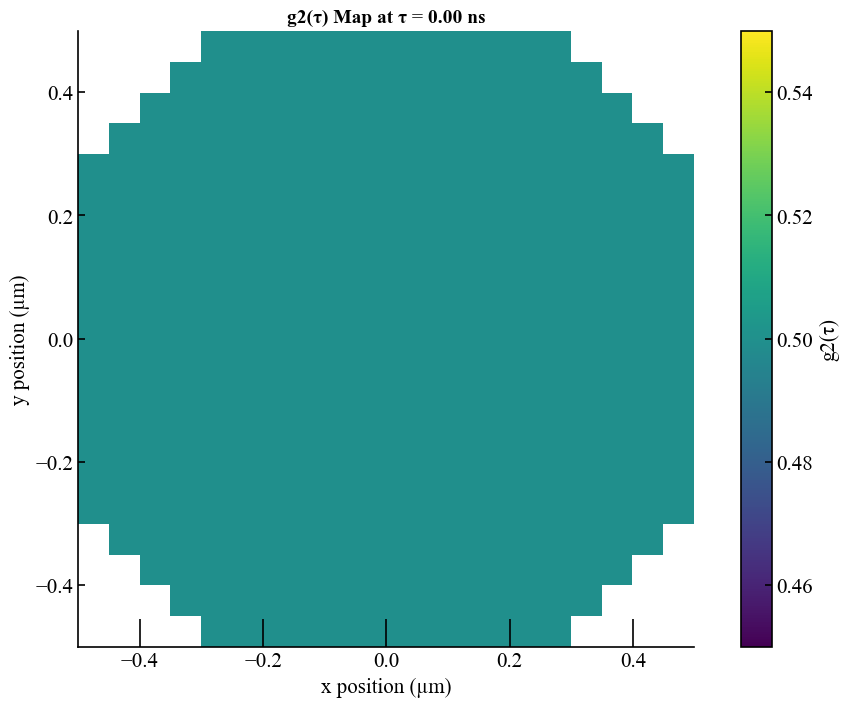

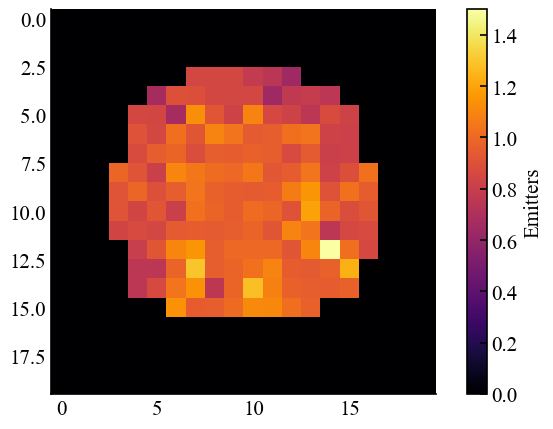

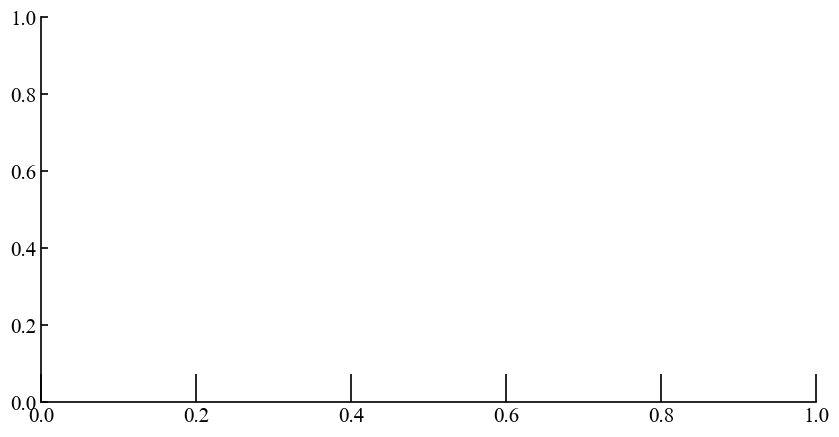

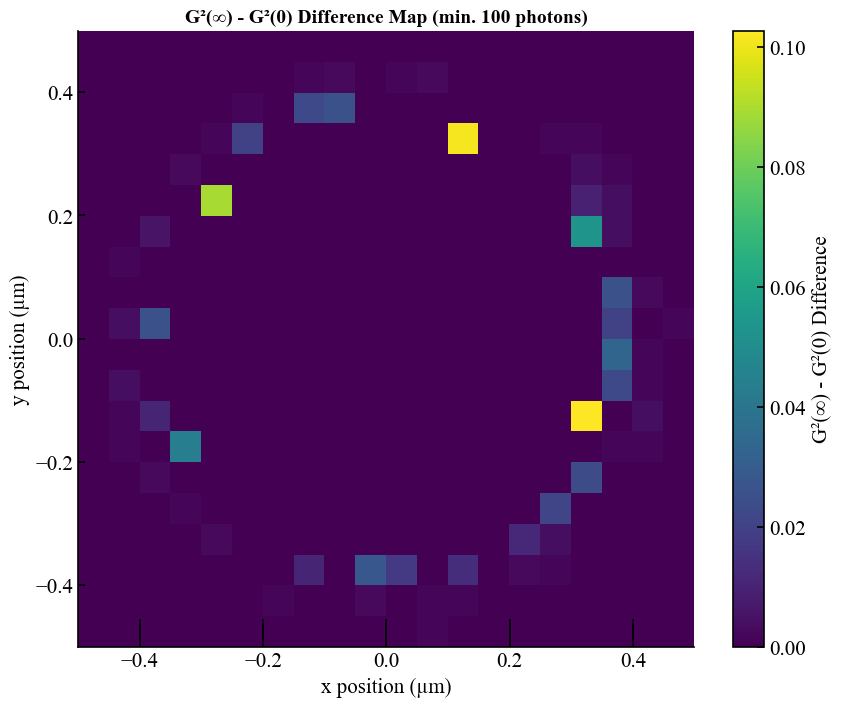

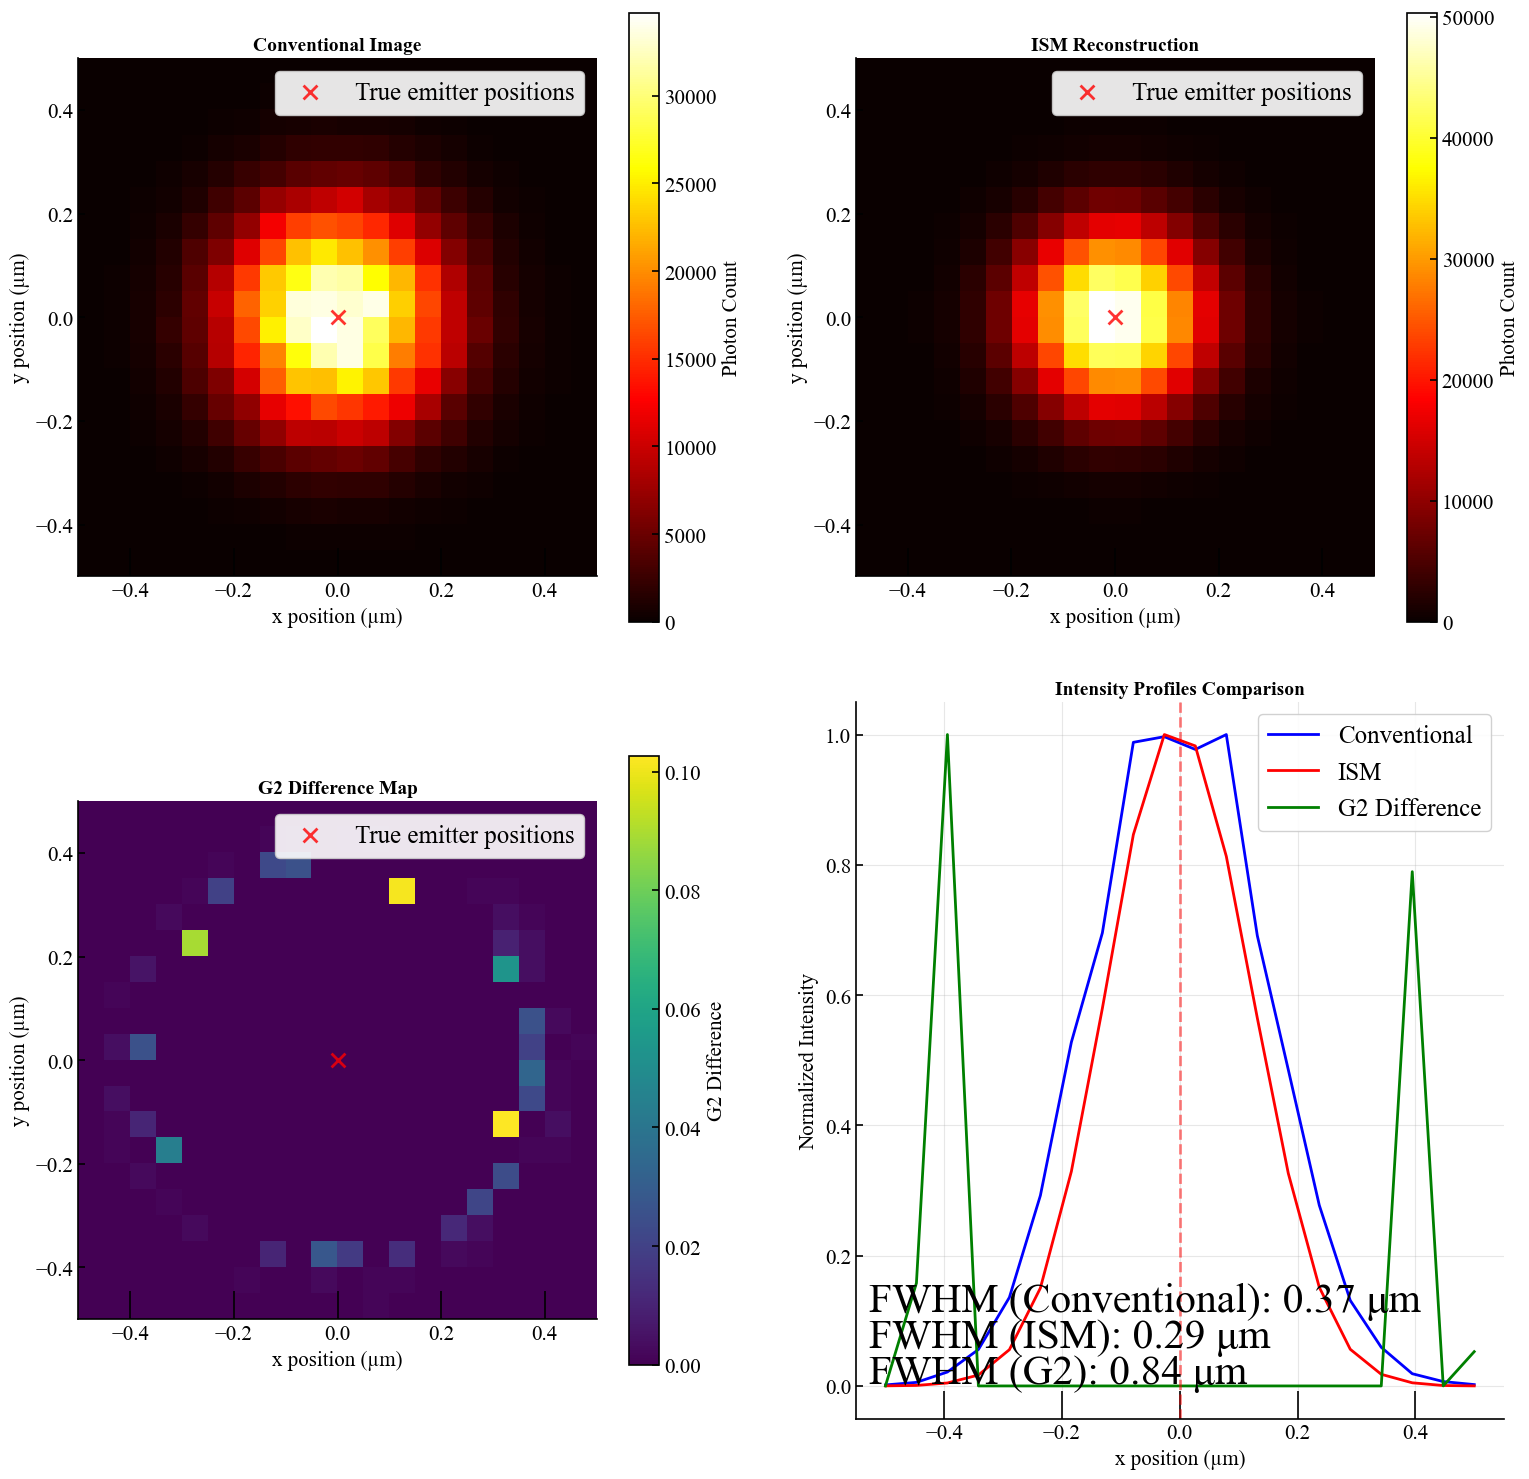

In [2]:
from project.simulations.run_scanning_experiment import run_scanning_experiment
from project.model.coherence_from_data import fit_coherence_function
from project.model.localization import localize
setup, photon_count_map, G2_diff_map, nr_emitters_map, metadata = run_scanning_experiment(
    positions =(20,20),
    laser_power= 10E3,
    area_size = (1,1),
    #emitters_manual = [(0,0)], #(-0.12, -0.12), (0.12, 0.12)],#[(0,0)], 
    emitters_manual = [(0,0)],
    #emitter_density= 9,
    #seed = 42,
    dwell_time = 2,
    show_plots=True, save_data=False, enable_noise=True, dead_time=50)


# setup, photon_count_map, G2_diff_map, nr_emitters_map, metadata = run_scanning_experiment(
#     positions = (20,20),
#     laser_power= 100E3,
#     area_size = (1,1),
#     #emitter_density = 5,
#     seed = 34,
#     dead_time = 50,
#     emitters_manual=[(0,0)],
#     enable_noise=True,
#     #emitters_manual = [(-0.12, -0.12), (0.12, 0.12)],
#     show_plots=True, save_data=False)


# localize

#localization = localize(photon_count_map.T, G2_diff_map.T, nr_emitters_map.T, metadata, plot = False, psf_file = 'project/data/psf.json', reg_weight=1000, verbose=False)

#print(localization)


In [ ]:
import random
def random_position():
    """
    Generates a random (x, y) position inside the square [(-0.5,0.5), (-0.5,0.5)].
    """
    x = random.uniform(-0.5, 0.5)
    y = random.uniform(-0.5, 0.5)
    return (x, y)

for _ in range(5):
    print(random_position())

    (0.4276619727318546, 0.47731928260913403)
(0.41412496862813686, -0.47227969496357636)
(-0.4622369999464352, 0.327327138307245)
(-0.0826086034900928, 0.015971226664519222)
(-0.46322959861831814, 0.3560546092649707)

(0.4276619727318546, 0.47731928260913403)
(0.41412496862813686, -0.47227969496357636)
(-0.4622369999464352, 0.327327138307245)
(-0.0826086034900928, 0.015971226664519222)
(-0.46322959861831814, 0.3560546092649707)


In [ ]:
import numpy as np

# Data from the 10 simulation results
confocal_sigma = [0.1617, 0.1598, 0.1630, 0.1643, 0.1625, 0.1657, 0.1609, 0.1607, 0.1614, 0.1636]
ism_sigma = [0.1379, 0.1361, 0.1370, 0.1373, 0.1374, 0.1364, 0.1379, 0.1371, 0.1376, 0.1367]
g2_confocal_sigma = [0.1157, 0.1177, 0.1210, 0.1209, 0.1208, 0.1261, 0.1174, 0.1172, 0.1176, 0.1206]
g2_ism_sigma = [0.0997, 0.0978, 0.0996, 0.0993, 0.0987, 0.1001, 0.0986, 0.1001, 0.0988, 0.0992]

# Convert to numpy arrays for easier calculations
confocal_sigma = np.array(confocal_sigma)
ism_sigma = np.array(ism_sigma)
g2_confocal_sigma = np.array(g2_confocal_sigma)
g2_ism_sigma = np.array(g2_ism_sigma)

print("=== ORIGINAL VALUES (μm) ===")
print(f"Confocal sigma - Mean: {np.mean(confocal_sigma):.4f}, Std: {np.std(confocal_sigma, ddof=1):.4f}")
print(f"ISM sigma - Mean: {np.mean(ism_sigma):.4f}, Std: {np.std(ism_sigma, ddof=1):.4f}")
print(f"G² Confocal sigma - Mean: {np.mean(g2_confocal_sigma):.4f}, Std: {np.std(g2_confocal_sigma, ddof=1):.4f}")
print(f"G² ISM sigma - Mean: {np.mean(g2_ism_sigma):.4f}, Std: {np.std(g2_ism_sigma, ddof=1):.4f}")

print("\n=== VALUES MULTIPLIED BY 2 (μm) ===")
print(f"Confocal sigma - Mean: {np.mean(confocal_sigma)*2:.4f}, Std: {np.std(confocal_sigma, ddof=1)*2:.4f}")
print(f"ISM sigma - Mean: {np.mean(ism_sigma)*2:.4f}, Std: {np.std(ism_sigma, ddof=1)*2:.4f}")
print(f"G² Confocal sigma - Mean: {np.mean(g2_confocal_sigma)*2:.4f}, Std: {np.std(g2_confocal_sigma, ddof=1)*2:.4f}")
print(f"G² ISM sigma - Mean: {np.mean(g2_ism_sigma)*2:.4f}, Std: {np.std(g2_ism_sigma, ddof=1)*2:.4f}")

# Also show individual values multiplied by 2
print("\n=== DETAILED BREAKDOWN ===")
print("Original data points:")
for i in range(10):
    print(f"#{i+1}: Confocal={confocal_sigma[i]:.4f}, ISM={ism_sigma[i]:.4f}, G²Confocal={g2_confocal_sigma[i]:.4f}, G²ISM={g2_ism_sigma[i]:.4f}")

print("\nData points multiplied by 2:")
for i in range(10):
    print(f"#{i+1}: Confocal={confocal_sigma[i]*2:.4f}, ISM={ism_sigma[i]*2:.4f}, G²Confocal={g2_confocal_sigma[i]*2:.4f}, G²ISM={g2_ism_sigma[i]*2:.4f}")


    # Calculate enhancement factors (resolution improvement relative to confocal)
# Enhancement factor = confocal_sigma / other_sigma (higher = better resolution)
print("\n=== ENHANCEMENT FACTORS (relative to Confocal) ===")

# Calculate for each individual measurement
ism_enhancement = confocal_sigma / ism_sigma
g2_confocal_enhancement = confocal_sigma / g2_confocal_sigma
g2_ism_enhancement = confocal_sigma / g2_ism_sigma

print("Individual enhancement factors:")
for i in range(10):
    print(f"#{i+1}: ISM={ism_enhancement[i]:.3f}x, G²Confocal={g2_confocal_enhancement[i]:.3f}x, G²ISM={g2_ism_enhancement[i]:.3f}x")

# Calculate mean enhancement factors
mean_ism_enhancement = np.mean(ism_enhancement)
mean_g2_confocal_enhancement = np.mean(g2_confocal_enhancement)
mean_g2_ism_enhancement = np.mean(g2_ism_enhancement)

std_ism_enhancement = np.std(ism_enhancement, ddof=1)
std_g2_confocal_enhancement = np.std(g2_confocal_enhancement, ddof=1)
std_g2_ism_enhancement = np.std(g2_ism_enhancement, ddof=1)

print(f"\nMean enhancement factors:")
print(f"ISM vs Confocal: {mean_ism_enhancement:.3f}x ± {std_ism_enhancement:.3f}")
print(f"G² Confocal vs Confocal: {mean_g2_confocal_enhancement:.3f}x ± {std_g2_confocal_enhancement:.3f}")
print(f"G² ISM vs Confocal: {mean_g2_ism_enhancement:.3f}x ± {std_g2_ism_enhancement:.3f}")

# Alternative calculation using mean values
print(f"\nEnhancement factors using mean sigma values:")
print(f"ISM: {np.mean(confocal_sigma)/np.mean(ism_sigma):.3f}x")
print(f"G² Confocal: {np.mean(confocal_sigma)/np.mean(g2_confocal_sigma):.3f}x") 
print(f"G² ISM: {np.mean(confocal_sigma)/np.mean(g2_ism_sigma):.3f}x")

=== ORIGINAL VALUES (μm) ===
Confocal sigma - Mean: 0.1624, Std: 0.0018
ISM sigma - Mean: 0.1371, Std: 0.0006
G² Confocal sigma - Mean: 0.1195, Std: 0.0030
G² ISM sigma - Mean: 0.0992, Std: 0.0007

=== VALUES MULTIPLIED BY 2 (μm) ===
Confocal sigma - Mean: 0.3247, Std: 0.0036
ISM sigma - Mean: 0.2743, Std: 0.0012
G² Confocal sigma - Mean: 0.2390, Std: 0.0060
G² ISM sigma - Mean: 0.1984, Std: 0.0015

=== DETAILED BREAKDOWN ===
Original data points:
#1: Confocal=0.1617, ISM=0.1379, G²Confocal=0.1157, G²ISM=0.0997
#2: Confocal=0.1598, ISM=0.1361, G²Confocal=0.1177, G²ISM=0.0978
#3: Confocal=0.1630, ISM=0.1370, G²Confocal=0.1210, G²ISM=0.0996
#4: Confocal=0.1643, ISM=0.1373, G²Confocal=0.1209, G²ISM=0.0993
#5: Confocal=0.1625, ISM=0.1374, G²Confocal=0.1208, G²ISM=0.0987
#6: Confocal=0.1657, ISM=0.1364, G²Confocal=0.1261, G²ISM=0.1001
#7: Confocal=0.1609, ISM=0.1379, G²Confocal=0.1174, G²ISM=0.0986
#8: Confocal=0.1607, ISM=0.1371, G²Confocal=0.1172, G²ISM=0.1001
#9: Confocal=0.1614, ISM=0.1

[{'x': np.float64(4.356602501887834), 'y': np.float64(4.262065004749672)}]
0.05


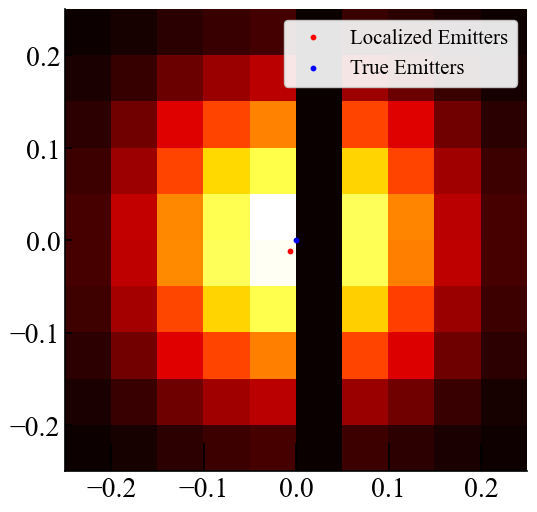

In [ ]:
print(localization['emitters'])
print(metadata['pixel_size'])
ps = metadata['pixel_size']
npos = metadata['positions'][0]
area_size = metadata['area_size']

real_pos = metadata['emitter_positions']

def transform_coordinates(x, y, area_size, npos,  direction = 'to_pixel'):
    """
    Transform coordinates between pixel and real space.
    
    Parameters:
    - x, y: Coordinates to transform.
    - direction: 'to_pixel' or 'to_physical'.
    - x_min, x_max: Real space limits in x.
    - y_min, y_max: Real space limits in y.
    - width, height: Dimensions of the pixel grid.
    
    Returns:
    - Transformed coordinates
    """
    xmin = -area_size[0]/2 + ps/2 # minimum coordinate
    ymin = -area_size[1]/2 + ps/2 # minimum coordinate

    if direction == 'to_pixel':
        x_transformed = npos * (x - xmin) / area_size[0]
        y_transformed = npos * (y - ymin) / area_size[1]
    elif direction == 'to_physical':
        x_transformed = x*area_size[0]/npos + xmin
        y_transformed = y*area_size[1]/npos + ymin
    else:
        raise ValueError("Direction must be 'to_pixel' or 'to_physical'")
    
    return x_transformed, y_transformed

# Transform emitter positions to real space
#real_pos = [transform_coordinates(x, y, area_size, npos, direction='to_pixel') for (x,y) in metadata['emitter_positions']]
loc_pos = [transform_coordinates(x['x'], x['y'], area_size, npos, direction='to_physical') for x in localization['emitters']]

import matplotlib.pyplot as plt

# get rid of very high values
nr_emitters_map_filtered = np.where(nr_emitters_map > 10, 5, nr_emitters_map)

plt.imshow(photon_count_map.T, cmap='hot', interpolation='nearest', extent = [-area_size[0]/2, area_size[0]/2, -area_size[1]/2, area_size[1]/2], origin='lower')
plt.scatter([x[0] for x in loc_pos], 
            [x[1] for x in loc_pos],
            c='red', s=10, label='Localized Emitters')
plt.scatter([x[0] for x in real_pos], 
            [x[1] for x in real_pos],
            c='blue', s=10, label='True Emitters')
#plt.plot([15,17], [18,18], color='white', linestyle='-')
#plt.text(0.75, 0.1, '100 nm', transform=plt.gca().transAxes, fontsize=16, color='white')

plt.legend()

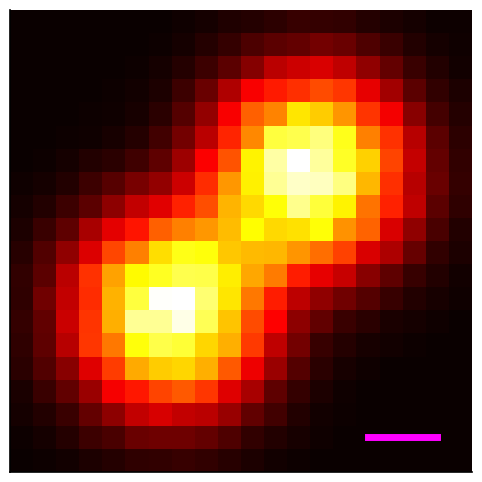

In [ ]:
# read h5 data
import h5py
with h5py.File('project/data/2025-06-18/sim_emitters2_size20_laser100kW_4f104b42.h5', 'r') as f:
    g2 = f['G2_diff'][:]
    emitters = f['nr_emitters'][:]
    counts = f['photon_counts'][:]


#plot image
plt.imshow(counts, cmap='hot', origin='lower')
#no numbers on the sides
plt.xticks([])
plt.yticks([])

# add distance bar white
plt.plot([15, 18], [1, 1], color='magenta', linewidth=5, alpha=1)